In [17]:
import numpy as np
import matplotlib.pyplot as plt
import os
%run environment.ipynb
%run agent.ipynb

In [18]:
env = create_env()

In [19]:
agent = QLearningAgent(
    env.observation_space.n,
    env.action_space.n
)

In [20]:
episodes = 10000        # Total number of training episodes
epsilon = 1.0           # Initial exploration rate
epsilon_decay = 0.995   # Decay rate for epsilon per episode
epsilon_min = 0.01      # Minimum exploration rate

In [21]:
rewards = []
steps = []

In [22]:
print("Starting training...")

Starting training...


In [23]:
window_size = 500

In [24]:
for episode in range(episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0
    episode_steps = 0

    while not done:
        action = agent.choose_action(state, epsilon, env.action_space)

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        agent.update(state, action, reward, next_state)

        state = next_state
        total_reward += reward
        episode_steps += 1

    rewards.append(total_reward)
    steps.append(episode_steps)

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if (episode + 1) % window_size == 0:
        avg_reward = np.mean(rewards[-window_size:])
        avg_steps = np.mean(steps[-window_size:])
        print(f"Episode {episode + 1}/{episodes} - Avg Reward: {avg_reward:.2f}, Avg Steps: {avg_steps:.2f}, Epsilon: {epsilon:.4f}")

Episode 500/10000 - Avg Reward: -319.69, Avg Steps: 147.10, Epsilon: 0.0816
Episode 1000/10000 - Avg Reward: -32.25, Avg Steps: 47.76, Epsilon: 0.0100
Episode 1500/10000 - Avg Reward: 1.47, Avg Steps: 18.96, Epsilon: 0.0100
Episode 2000/10000 - Avg Reward: 5.96, Avg Steps: 14.61, Epsilon: 0.0100
Episode 2500/10000 - Avg Reward: 7.31, Avg Steps: 13.39, Epsilon: 0.0100
Episode 3000/10000 - Avg Reward: 7.12, Avg Steps: 13.52, Epsilon: 0.0100
Episode 3500/10000 - Avg Reward: 7.22, Avg Steps: 13.35, Epsilon: 0.0100
Episode 4000/10000 - Avg Reward: 7.47, Avg Steps: 13.24, Epsilon: 0.0100
Episode 4500/10000 - Avg Reward: 7.43, Avg Steps: 13.30, Epsilon: 0.0100
Episode 5000/10000 - Avg Reward: 7.21, Avg Steps: 13.32, Epsilon: 0.0100
Episode 5500/10000 - Avg Reward: 7.43, Avg Steps: 13.17, Epsilon: 0.0100
Episode 6000/10000 - Avg Reward: 7.55, Avg Steps: 13.11, Epsilon: 0.0100
Episode 6500/10000 - Avg Reward: 7.17, Avg Steps: 13.52, Epsilon: 0.0100
Episode 7000/10000 - Avg Reward: 7.43, Avg Ste

In [25]:
print("Training finished.")
np.save("../model/q_table.npy", agent.q_table)

Training finished.


In [26]:
print("Generating learning curves...")

Generating learning curves...


In [27]:
def moving_average(a, n=window_size):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

In [28]:
smoothed_rewards = moving_average(rewards)
smoothed_steps = moving_average(steps)

In [29]:
os.makedirs("../data", exist_ok=True)

Learning curves saved to data/learning_curves.png.


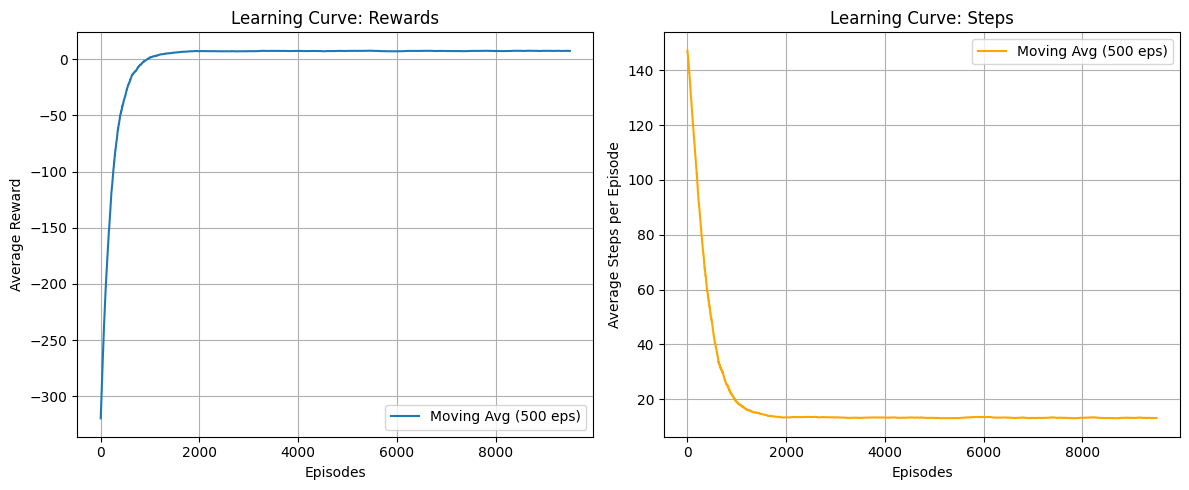

In [30]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(smoothed_rewards, label=f"Moving Avg ({window_size} eps)")
plt.xlabel("Episodes")
plt.ylabel("Average Reward")
plt.title("Learning Curve: Rewards")
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(smoothed_steps, label=f"Moving Avg ({window_size} eps)", color="orange")
plt.xlabel("Episodes")
plt.ylabel("Average Steps per Episode")
plt.title("Learning Curve: Steps")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../data/learning_curves.png")
print("Learning curves saved to data/learning_curves.png.")